In [1]:
# Phase 4 — Weather Forecasting Models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv('cleaned_weather_data.csv')
df['last_updated'] = pd.to_datetime(df['last_updated'])

# Create time series: daily average temperature
daily_temp = df.groupby('last_updated')['temperature_celsius'].mean().reset_index()
daily_temp = daily_temp.sort_values('last_updated')
daily_temp['day_number'] = range(len(daily_temp))

print("Daily temperature records:", len(daily_temp))
print(daily_temp.head())

Daily temperature records: 23508
         last_updated  temperature_celsius  day_number
0 2024-05-16 01:45:00            16.100000           0
1 2024-05-16 02:45:00            23.428571           1
2 2024-05-16 03:45:00            19.100000           2
3 2024-05-16 04:45:00            22.255000           3
4 2024-05-16 05:45:00            12.800000           4


In [2]:
# Build features for ML models
def create_features(df):
    df = df.copy()
    df['hour'] = df['last_updated'].dt.hour
    df['month'] = df['last_updated'].dt.month
    df['day_of_week'] = df['last_updated'].dt.dayofweek
    df['day_of_year'] = df['last_updated'].dt.dayofyear
    # Lag features (previous temperatures)
    df['temp_lag1'] = df['temperature_celsius'].shift(1)
    df['temp_lag24'] = df['temperature_celsius'].shift(24)
    df['temp_rolling7'] = df['temperature_celsius'].rolling(7).mean()
    return df.dropna()

daily_temp = create_features(daily_temp)

# Features and target
feature_cols = ['day_number', 'hour', 'month', 'day_of_week', 
                'day_of_year', 'temp_lag1', 'temp_lag24', 'temp_rolling7']
X = daily_temp[feature_cols]
y = daily_temp['temperature_celsius']

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

# Model 2: Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# Compare models
def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae:.2f}°C  RMSE={rmse:.2f}°C  R²={r2:.3f}")

print("\n=== Model Comparison ===")
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest    ", y_test, rf_pred)

Training samples: 18787
Testing samples:  4697

=== Model Comparison ===
Linear Regression: MAE=4.36°C  RMSE=6.02°C  R²=0.302
Random Forest    : MAE=4.48°C  RMSE=5.90°C  R²=0.330


=== All Models Comparison ===
Linear Regression: MAE=4.36°C  RMSE=6.02°C  R²=0.302
Random Forest    : MAE=4.48°C  RMSE=5.90°C  R²=0.330
XGBoost          : MAE=4.04°C  RMSE=5.26°C  R²=0.466
Ensemble (avg)   : MAE=4.07°C  RMSE=5.29°C  R²=0.461


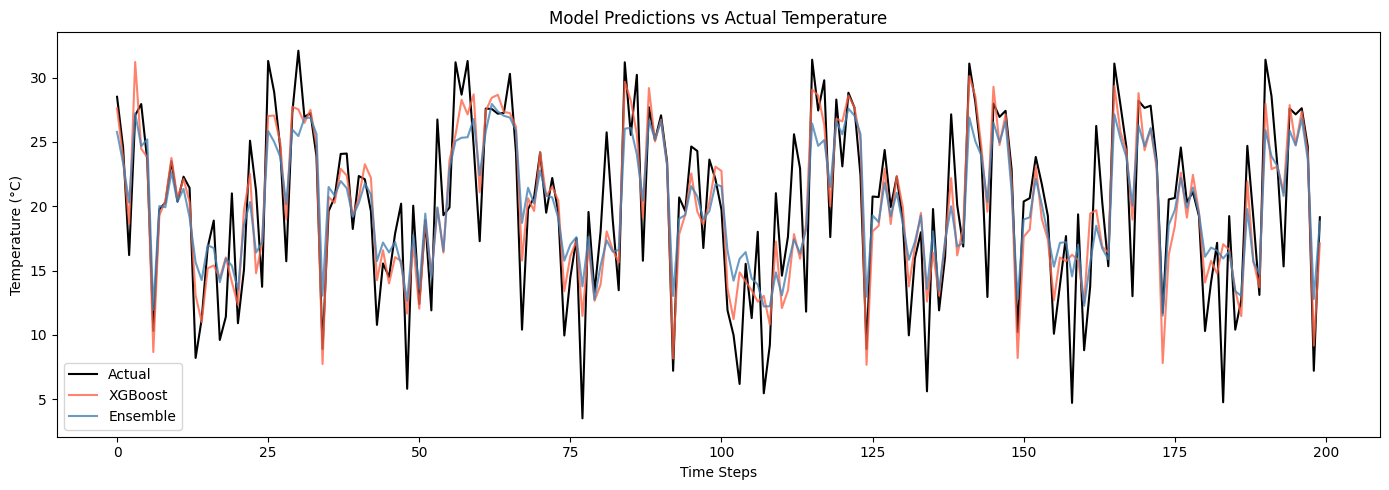

In [3]:
# Model 3: XGBoost
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, 
                               max_depth=6, random_state=42, verbosity=0)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

# Model 4: Ensemble (average of all 3)
ensemble_pred = (lr_pred + rf_pred + xgb_pred) / 3

print("=== All Models Comparison ===")
evaluate("Linear Regression", y_test, lr_pred)
evaluate("Random Forest    ", y_test, rf_pred)
evaluate("XGBoost          ", y_test, xgb_pred)
evaluate("Ensemble (avg)   ", y_test, ensemble_pred)

# Visualize predictions vs actual
plt.figure(figsize=(14, 5))
sample = range(200)
plt.plot(y_test.values[:200], label='Actual', color='black', linewidth=1.5)
plt.plot(xgb_pred[:200], label='XGBoost', color='tomato', alpha=0.8)
plt.plot(ensemble_pred[:200], label='Ensemble', color='steelblue', alpha=0.8)
plt.title('Model Predictions vs Actual Temperature')
plt.xlabel('Time Steps')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.savefig('plot_predictions.png', dpi=150)
plt.show()

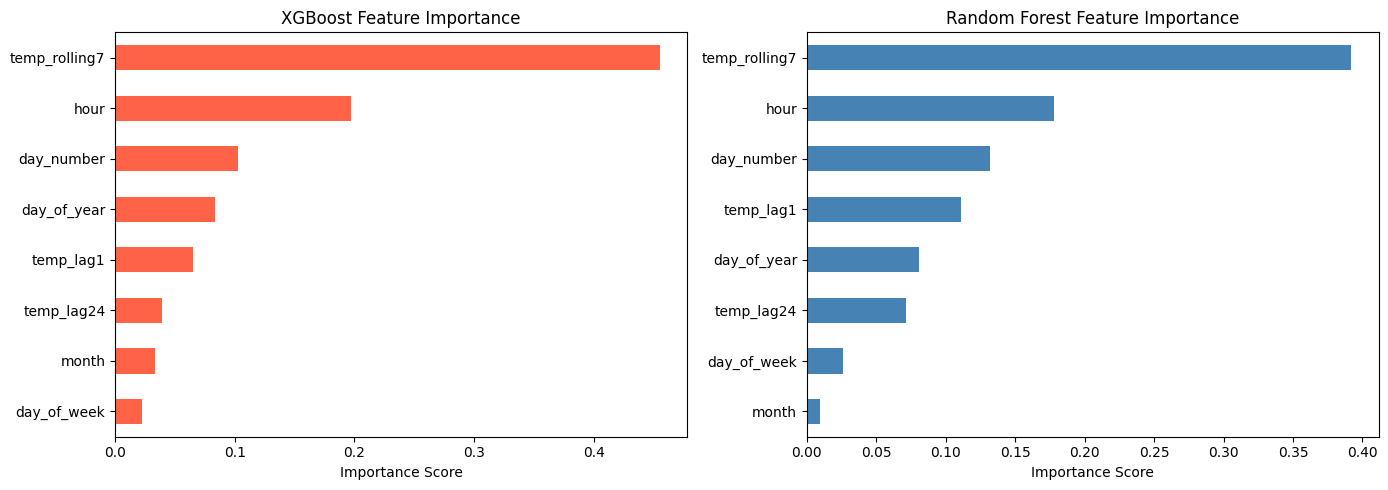

✅ Feature importance saved!


In [4]:
# Feature Importance (which variables matter most?)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XGBoost feature importance
xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols)
xgb_importance.sort_values().plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('XGBoost Feature Importance')
axes[0].set_xlabel('Importance Score')

# Random Forest feature importance
rf_importance = pd.Series(rf.feature_importances_, index=feature_cols)
rf_importance.sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Random Forest Feature Importance')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150)
plt.show()
print("✅ Feature importance saved!")